In [21]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras

In [22]:
import torch
torch.cuda.is_available()

True

In [23]:
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy
from keras.datasets import mnist

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
def build_model(activation: str = 'relu'):
  model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(units=128, activation=activation),
    Dense(128, activation=activation),
    Dense(128, activation=activation),
    Dense(10, activation='softmax'), #10 categories of dogs
    # Dense(1,activation='linear'), # 1 stock price 
    # Dense(1, activation='sigmoid') # 1 "boolean"
  
  ])


  model.compile(optimizer=Adam(), 
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model


model = build_model()
model.summary()


  

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('x_train.shape: ', x_train.shape)
print('y_train.shape: ', y_train.shape)
print('x_test.shape: ', x_test.shape)
print('y_test.shape: ', y_test.shape)

x_train.shape:  (60000, 28, 28)
y_train.shape:  (60000,)
x_test.shape:  (10000, 28, 28)
y_test.shape:  (10000,)


In [74]:


model.fit(
  x_train, 
  y_train,
  batch_size=1024,
  epochs=10,
  validation_split=0.2
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8591 - loss: 2.1481 - val_accuracy: 0.8561 - val_loss: 2.1479
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8621 - loss: 2.1118 - val_accuracy: 0.8543 - val_loss: 2.1518
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8633 - loss: 2.0819 - val_accuracy: 0.8576 - val_loss: 2.1181
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8665 - loss: 2.0435 - val_accuracy: 0.8592 - val_loss: 2.0884
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8694 - loss: 2.0157 - val_accuracy: 0.8583 - val_loss: 2.1000
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8702 - loss: 2.0021 - val_accuracy: 0.8585 - val_loss: 2.1033
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8722 - loss: 1.9806 - val_accuracy: 0.8584 - val_loss: 2.0789
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8730 - loss: 1.9692 - val_accuracy: 0.8608 - val_loss

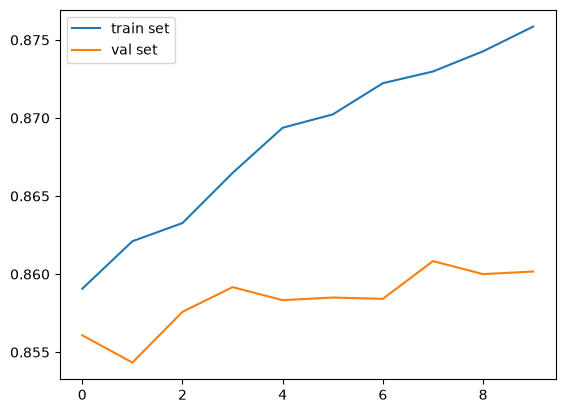

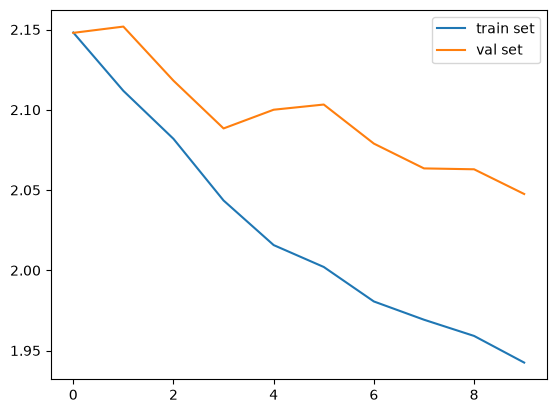

In [77]:
logs = model.history.history
plt.Figure(figsize=(12,7))
# sns.lineplot(logs)
plt.plot(logs['accuracy'], label="train set")
plt.plot(logs['val_accuracy'], label="val set")
plt.legend()
plt.show()

plt.Figure(figsize=(12,7))
# sns.lineplot(logs)
plt.plot(logs['loss'], label="train set")
plt.plot(logs['val_loss'], label="val set")
plt.legend()
plt.show()

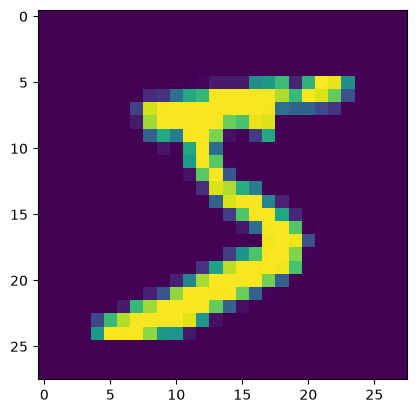

In [27]:
plt.imshow(x_train[0])

In [28]:
x_train[0].ravel() # == Flatten()  (pixel values of the first image)

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17